<a href="https://colab.research.google.com/github/FC-Andrade/Syndecan_4-Ag73/blob/main/Energy_MM_PBSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [ ]:
# =========================================
# 2. UPLOAD DOS ARQUIVOS (COLAB)
# =========================================
from google.colab import files

print("⬆️ Faça upload dos arquivos CSV (Ctrl + clique para selecionar vários):")
uploaded = files.upload()

# Verifica se arquivos foram enviados
if len(uploaded) == 0:
    raise ValueError("Nenhum arquivo foi enviado!")

print(f"\nArquivos carregados: {list(uploaded.keys())}")


⬆️ Faça upload dos arquivos CSV (Ctrl + clique para selecionar vários):


Saving Syndag73_1.csv to Syndag73_1.csv
Saving Syndag73_2.csv to Syndag73_2.csv
Saving syndag73_3.csv to syndag73_3.csv

Arquivos carregados: ['Syndag73_1.csv', 'Syndag73_2.csv', 'syndag73_3.csv']


In [ ]:
# =========================================
# 3. DADOS (SUAS TABELAS)
# =========================================
rep1 = {
    "VDWAALS": -43.34, "EEL": 127.7,
    "EGB": -118.48, "ESURF": -7.83,
    "GGAS": 84.36, "GSOLV": -126.3, "TOTAL": -41.95
}

rep2 = {
    "VDWAALS": -38.6, "EEL": 184.71,
    "EGB": -178.67, "ESURF": -6.94,
    "GGAS": 146.11, "GSOLV": -185.62, "TOTAL": -39.51
}

rep3 = {
    "VDWAALS": -51.69, "EEL": 164.94,
    "EGB": -157.78, "ESURF": -9.63,
    "GGAS": 113.24, "GSOLV": -167.42, "TOTAL": -54.17
}

df = pd.DataFrame([rep1, rep2, rep3])



In [ ]:
# =========================================
# 4. MÉDIA E DESVIO ENTRE RÉPLICAS
# =========================================
mean = df.mean()
std = df.std()


/tmp/ipykernel_15326/1040385742.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

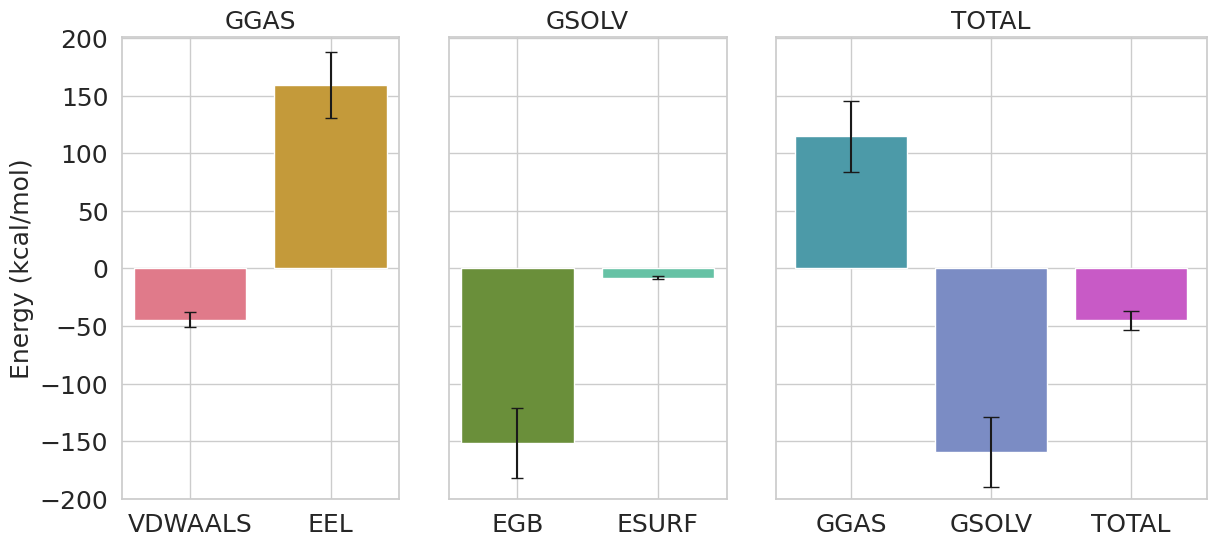

In [ ]:
# =========================================
# 5. PLOT ESTILO DO SEU GRÁFICO
# =========================================
sns.set(style="whitegrid")

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 6),
    sharey=True,
    gridspec_kw={'width_ratios': [1, 1, 1.55], 'wspace': 0.15}
)


# Paleta semelhante ao seu gráfico
cores = {
    "VDWAALS": "#e07a8a",
    "EEL": "#c49a3a",
    "EGB": "#6a8f3a",
    "ESURF": "#66c2a5",
    "GGAS": "#4c9aa8",
    "GSOLV": "#7b8cc4",
    "TOTAL": "#c85ac6"
}

# ================= GGAS =================
labels = ["VDWAALS", "EEL"]
axes[0].bar(labels, mean[labels], yerr=std[labels], capsize=4,
            color=[cores[l] for l in labels])
axes[0].set_title("GGAS")

# ================= GSOLV =================
labels = ["EGB", "ESURF"]
axes[1].bar(labels, mean[labels], yerr=std[labels], capsize=4,
            color=[cores[l] for l in labels])
axes[1].set_title("GSOLV")

# ================= TOTAL =================
labels = ["GGAS", "GSOLV", "TOTAL"]
axes[2].bar(labels, mean[labels], yerr=std[labels], capsize=6,
            color=[cores[l] for l in labels])
axes[2].set_title("TOTAL")

import numpy as np

# Definir limites do eixo Y (ajuste se quiser)
ymin = -200
ymax = 201

# Aplicar em todos os gráficos
for ax in axes:
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.arange(ymin, ymax + 0, 50))  # escala de 100 em 100

axes[0].set_ylabel("Energy (kcal/mol)", fontsize=20)

axes[0].set_title("GGAS", fontsize=18)
axes[1].set_title("GSOLV", fontsize=18)
axes[2].set_title("TOTAL", fontsize=18)

axes[0].set_ylabel("Energy (kcal/mol)", fontsize=18)

for ax in axes:
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)

# =========================================
# SALVAR CORRETAMENTE (ANTES DO SHOW)

fig.tight_layout()

# Salva usando o objeto da figura (ESSENCIAL)
fig.savefig("grafico_final.png", dpi=600, bbox_inches="tight")


# =========================================
# DOWNLOAD

from google.colab import files
files.download("grafico_final.png")


In [ ]:
# =========================================
# 10. GERAR TABELA FINAL
# =========================================

# Número de réplicas
n = len(df)

# SEM (erro padrão)
sem = std / np.sqrt(n)

# Criar tabela no formato desejado
tabela_final = pd.DataFrame([mean, std, sem],
                           index=["Average", "SD", "SEM"])

# Ajustar ordem das colunas
colunas = ["VDWAALS", "EEL", "EGB", "ESURF", "GGAS", "GSOLV", "TOTAL"]
tabela_final = tabela_final[colunas]

print("\n📊 Tabela final:")
print(tabela_final.round(2))



📊 Tabela final:
         VDWAALS     EEL     EGB  ESURF    GGAS   GSOLV  TOTAL
Average   -44.54  159.12 -151.64  -8.13  114.57 -159.78 -45.21
SD          6.63   28.95   30.56   1.37   30.90   30.39   7.85
SEM         3.83   16.71   17.64   0.79   17.84   17.55   4.54


In [ ]:
tabela_final.round(2).to_csv("tabela_final.csv")

from google.colab import files
files.download("tabela_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>